# <span style = 'color:coral'>Gradient Descent</span>
- simple linear Regression

In [ ]:
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('salary.csv')
df.head()

,S_no,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [27]:
df.pop('S_no')

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
20    20
21    21
22    22
23    23
24    24
25    25
26    26
27    27
28    28
29    29
Name: S_no, dtype: int64

In [28]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [29]:
df.rename(columns = {
    'YearsExperience':'exp',
    'Salary':'salary'
},inplace = True)

In [30]:
# features and target
x = df.iloc[:, 0]
y = df.iloc[:, -1]

In [31]:
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

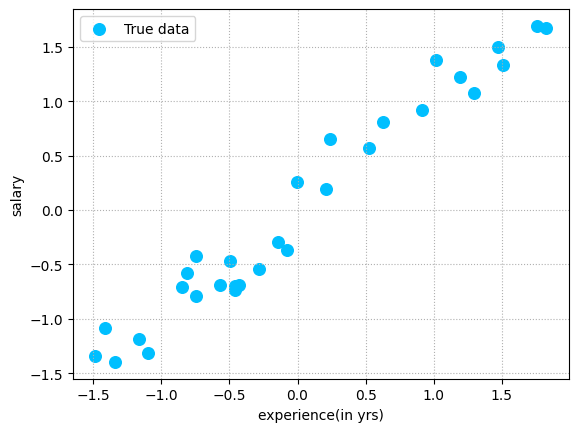

In [32]:
# true data
plt.scatter(x,y,color = 'deepskyblue', s = 70, label = 'True data')
plt.xlabel('experience(in yrs)')
plt.ylabel('salary')
plt.legend()
plt.grid(axis ='both', ls = 'dotted')
plt.show()

In [33]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [34]:
# custom class GD
class GD:
    def __init__(self, learning_rate, epochs):
        self.m = None
        self.b = None
        self.n = learning_rate
        self.epochs = epochs
        self.loss_list = []
    
    def fit(self, x_train, y_train):
        # random init
        self.m = 1
        self.b = 0

        for i in range(self.epochs):
            # updating the intercept
            y_pred = self.m * x_train + self.b
            grad_b = (-2/x_train.shape[0]) * np.sum(y_train - y_pred)
            self.b -= (self.n * grad_b)

            # updating the slope
            grad_m = (-2/x_train.shape[0]) * np.sum((y_train - y_pred) * x_train)
            self.m -= (self.n * grad_m)
    
            loss = np.mean((y_pred - y_train)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        
        print('final parameters...')
        print('m = ',self.m)
        print('b = ',self.b)
    
    def predict(self, x_test):
        return self.m * x_test + self.b

In [46]:
gd = GD(0.1, 100)
gd.fit(x_train, y_train)

step 0 | loss = 0.035417319425150355
step 1 | loss = 0.035060614545029914
step 2 | loss = 0.034842066952523766
step 3 | loss = 0.03470792504464681
step 4 | loss = 0.03462542919084595
step 5 | loss = 0.03457458762329931
step 6 | loss = 0.03454318279305826
step 7 | loss = 0.034523736495745
step 8 | loss = 0.03451166357661361
step 9 | loss = 0.03450414746775035
step 10 | loss = 0.0344994545058409
step 11 | loss = 0.034496515246217406
step 12 | loss = 0.03449466842795979
step 13 | loss = 0.03449350414851549
step 14 | loss = 0.03449276763505917
step 15 | loss = 0.034492300084180756
step 16 | loss = 0.03449200221467213
step 17 | loss = 0.034491811762615864
step 18 | loss = 0.03449168955169094
step 19 | loss = 0.03449161084888459
step 20 | loss = 0.03449155998537424
step 21 | loss = 0.03449152699949599
step 22 | loss = 0.034491505535257434
step 23 | loss = 0.03449149152260952
step 24 | loss = 0.03449148234591036
step 25 | loss = 0.03449147631819643
step 26 | loss = 0.03449147234763133
step 27

In [47]:
y_pred = gd.predict(x_test)

In [48]:
# evaluation
from sklearn.metrics import r2_score
r2_sc = r2_score(y_test, y_pred)
r2_sc

0.8886956734004244

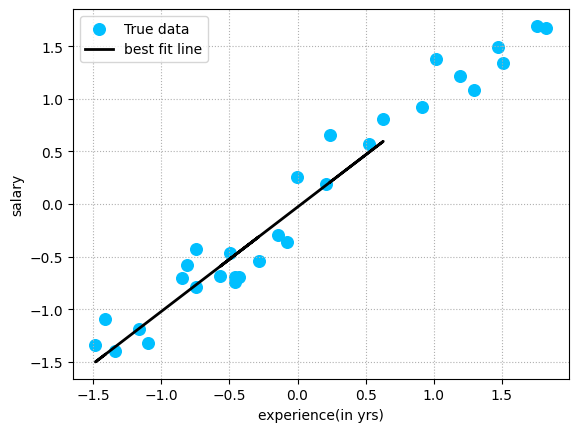

In [49]:
# best fit line
plt.scatter(x,y,color = 'deepskyblue', s = 70, label = 'True data')
plt.plot(x_test, y_pred, color = 'k', lw = 2, label = 'best fit line')
plt.xlabel('experience(in yrs)')
plt.ylabel('salary')
plt.legend()
plt.grid(axis ='both', ls = 'dotted')
plt.show()

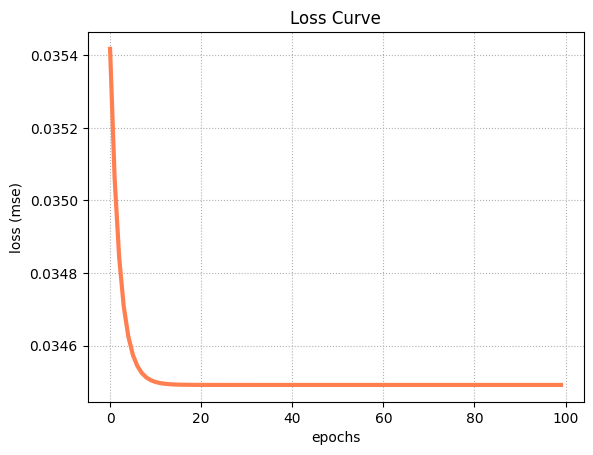

In [50]:
# loss curve
plt.plot(range(gd.epochs), gd.loss_list, color = 'coral', lw = 3, label = 'loss')
plt.xlabel('epochs')
plt.ylabel('loss (mse)')
plt.title('Loss Curve')
plt.grid(axis ='both', ls = 'dotted')
plt.show()